In [1]:
%load_ext autoreload
%autoreload 2

In [29]:
import numpy as np
from ion_simulbox import Ion
from ion_simulbox.laser import Laser, PulseLaser, Polarization, EnvelopeFactory
from ion_simulbox.experiment import Experiment
from ion_simulbox.units import Units, Constants
from ion_simulbox.utils import get_resonant_frequency
from ion_simulbox.transition import Transition

In [215]:
from ion_simulbox.systems.single_laser_system import SingleLaserSystem
from ion_simulbox.systems.lambda_system import LambdaSystem

In [221]:
import matplotlib.pyplot as plt

In [216]:
ion = Ion("Ba", 138)

## 1. CW 493

In [264]:
laser_493 = Laser(
    name="493 nm",
    frequency=get_resonant_frequency(ion.energy_levels[0], ion.energy_levels[1]),
    intensity=500, 
    line_width=10 * Units.kHz, 
    polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
)

In [265]:
system = SingleLaserSystem(
    ion=ion,
    lower_states=ion.zeeman_levels[ion.get_level("6S0.5")],
    upper_states=ion.zeeman_levels[ion.get_level("6P0.5")],
    laser=laser_493,
    envelope_function=EnvelopeFactory.square_factory(0, 1000e-9),
    reference_state=ion.zeeman_levels[ion.get_level("6S0.5")][0],
)

In [266]:
initial_state = system.basis[ion.zeeman_levels[ion.get_level("6S0.5")][0]]
t_list = np.linspace(0, 1000, 30001) * 1e-9
expect_values, final_state = system.solve(initial_state, t_list)

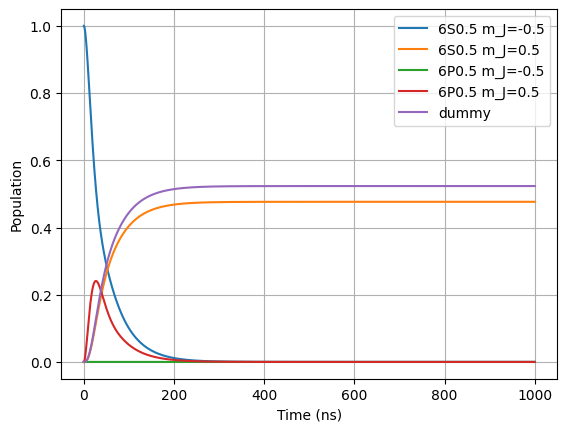

In [267]:
fig = plt.figure()
ax = fig.add_subplot(111)
for name, expect in expect_values.items():
    ax.plot(t_list/1e-9, expect, label=name)
ax.legend()
ax.set_ylabel("Population")
ax.set_xlabel("Time (ns)")
ax.grid()

## 2. Pulse excitation

In [218]:
laser_493 = Laser(
    name="493 nm",
    frequency=get_resonant_frequency(ion.energy_levels[0], ion.energy_levels[1]),
    intensity=9.1e8,
    line_width=10 * Units.kHz, 
    polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
)

In [219]:
system = SingleLaserSystem(
    ion=ion,
    lower_states=ion.zeeman_levels[ion.get_level("6S0.5")],
    upper_states=ion.zeeman_levels[ion.get_level("6P0.5")],
    laser=laser_493,
    envelope_function=EnvelopeFactory.gaussian_factory(50e-12, 10e-12),
    reference_state=ion.zeeman_levels[ion.get_level("6S0.5")][0],
)

In [220]:
initial_state = system.basis[ion.zeeman_levels[ion.get_level("6S0.5")][0]]
t_list = np.linspace(0, 100000, 30001) * 1e-12
expect_values, final_state = system.solve(initial_state, t_list)

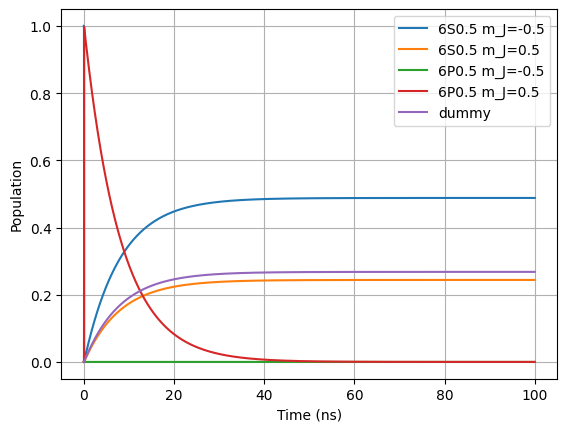

In [222]:
fig = plt.figure()
ax = fig.add_subplot(111)
for name, expect in expect_values.items():
    ax.plot(t_list/1e-9, expect, label=name)
ax.legend()
ax.set_ylabel("Population")
ax.set_xlabel("Time (ns)")
ax.grid()

## Initialization single detuning

In [339]:
ion.apply_magnetic_field(1e-8*Units.T)

In [479]:
laser_493 = Laser(
    name="493 nm",
    frequency=get_resonant_frequency(ion.energy_levels[0], ion.energy_levels[1]) + 10 * Units.MHz,
    intensity=2000, # 9.1e8 
    line_width=10 * Units.kHz, 
    polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
)

In [480]:
laser_650 = Laser(
    name="650 nm",
    frequency=get_resonant_frequency(ion.energy_levels[1], ion.energy_levels[3]) + 0 * Units.MHz,
    intensity=2000, 
    line_width=10 * Units.kHz, 
    # polarization=Polarization(-np.array([1, 0, 0]), 1 / np.sqrt(2), 1j / np.sqrt(2))
    polarization=Polarization(np.array([0, 1, 1])/np.sqrt(2), 1, 0)
)

In [481]:
system = LambdaSystem(
    ion=ion,
    lower_states_1=ion.zeeman_levels[ion.get_level("6S0.5")],
    lower_states_2=ion.zeeman_levels[ion.get_level("5D1.5")],
    upper_states=ion.zeeman_levels[ion.get_level("6P0.5")],
    laser_1=laser_493,
    laser_2=laser_650,
    envelope_function_1=EnvelopeFactory.square_factory(0, 5000e-9),
    envelope_function_2=EnvelopeFactory.square_factory(0, 5000e-9),
    reference_state=ion.zeeman_levels[ion.get_level("6P0.5")][0],
)

In [482]:
initial_state = system.basis[ion.zeeman_levels[ion.get_level("6S0.5")][0]]
t_list = np.linspace(0, 2000, 3001) * 1e-9
expect_values, final_state = system.solve(initial_state, t_list)

In [485]:
expect_values

{'6S0.5 m_J=-0.5': array([1.00000000e+00, 9.96195029e-01, 9.85252300e-01, ...,
        1.81302221e-05, 1.80711070e-05, 1.80111507e-05], shape=(3001,)),
 '6S0.5 m_J=0.5': array([0.00000000e+00, 2.56912471e-05, 1.98587945e-04, ...,
        6.53490845e-01, 6.53490977e-01, 6.53491110e-01], shape=(3001,)),
 '5D1.5 m_J=-1.5': array([0.00000000e+00, 1.08314526e-12, 6.84522553e-11, ...,
        3.79211390e-02, 3.79211471e-02, 3.79211552e-02], shape=(3001,)),
 '5D1.5 m_J=-0.5': array([0.00000000e+00, 4.89753098e-06, 3.93589120e-05, ...,
        3.48169411e-02, 3.48169969e-02, 3.48170525e-02], shape=(3001,)),
 '5D1.5 m_J=0.5': array([0.00000000e+00, 1.01850286e-05, 8.47586588e-05, ...,
        9.51278281e-02, 9.51279144e-02, 9.51280000e-02], shape=(3001,)),
 '5D1.5 m_J=1.5': array([0.00000000e+00, 1.46931853e-05, 1.18094689e-04, ...,
        1.78618879e-01, 1.78618670e-01, 1.78618462e-01], shape=(3001,)),
 '6P0.5 m_J=-0.5': array([0.00000000e+00, 5.86482857e-10, 1.75882777e-08, ...,
        2.52

In [488]:
"S" in list(expect_values.keys())[0]

True

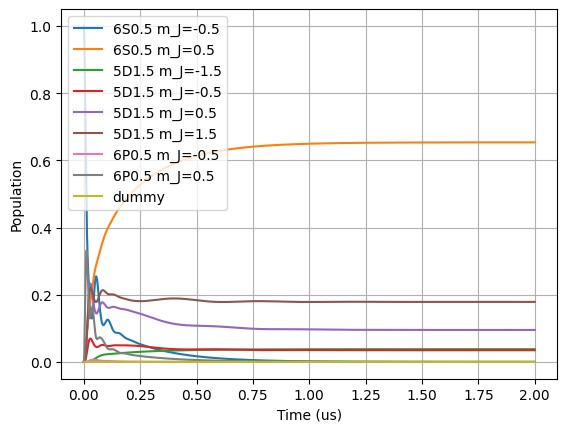

In [483]:
fig = plt.figure()
ax = fig.add_subplot(111)
for name, expect in expect_values.items():
    ax.plot(t_list/1e-6, expect, label=name)
ax.legend()
ax.set_ylabel("Population")
ax.set_xlabel("Time (us)")
ax.grid()

## Initialization single detuning sweep

In [490]:
detunning_493 = np.linspace(-10, 10, 21) * Units.MHz
detunning_650 = np.linspace(-10, 10, 21) * Units.MHz
population_S = []
population_P = []
population_D = []
population_dummy = []
for delta_493 in detunning_493:
    print("#", end="")
    population_S.append([])
    population_P.append([])
    population_D.append([])
    population_dummy.append([])
    for delta_650 in detunning_650:
        print("*", end="")
        laser_493 = Laser(
            name="493 nm",
            frequency=get_resonant_frequency(ion.energy_levels[0], ion.energy_levels[1]) + delta_493,
            intensity=2000, # 9.1e8 
            line_width=10 * Units.kHz, 
            polarization=Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
        )
        laser_650 = Laser(
            name="650 nm",
            frequency=get_resonant_frequency(ion.energy_levels[1], ion.energy_levels[3]) + delta_650,
            intensity=2000, 
            line_width=10 * Units.kHz, 
            # polarization=Polarization(-np.array([1, 0, 0]), 1 / np.sqrt(2), 1j / np.sqrt(2))
            polarization=Polarization(np.array([0, 1, 1])/np.sqrt(2), 1, 0)
        )
        
        system = LambdaSystem(
            ion=ion,
            lower_states_1=ion.zeeman_levels[ion.get_level("6S0.5")],
            lower_states_2=ion.zeeman_levels[ion.get_level("5D1.5")],
            upper_states=ion.zeeman_levels[ion.get_level("6P0.5")],
            laser_1=laser_493,
            laser_2=laser_650,
            envelope_function_1=EnvelopeFactory.square_factory(0, 5000e-9),
            envelope_function_2=EnvelopeFactory.square_factory(0, 5000e-9),
            reference_state=ion.zeeman_levels[ion.get_level("6P0.5")][0],
        )
        initial_state = system.basis[ion.zeeman_levels[ion.get_level("6S0.5")][0]]
        t_list = np.linspace(0, 2000, 3001) * 1e-9
        expect_values, final_state = system.solve(initial_state, t_list)
        P_S = 0
        P_P = 0
        P_D = 0
        P_dummy = 0
        for k, v in expect_values.items():
            if "S" in k:
                P_S = P_S + v
            elif "P" in k:
                P_P = P_P + v
            elif "D" in k:
                P_D = P_D + v 
            else:
                P_dummy = P_dummy + v
        population_S[-1].append(P_S)
        population_P[-1].append(P_P)
        population_D[-1].append(P_D)
        population_dummy[-1].append(P_dummy)
    print("")

#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************
#*********************


In [494]:
np.array(population_S).shape

(21, 21, 3001)

Text(0, 0.5, '650nm detuning')

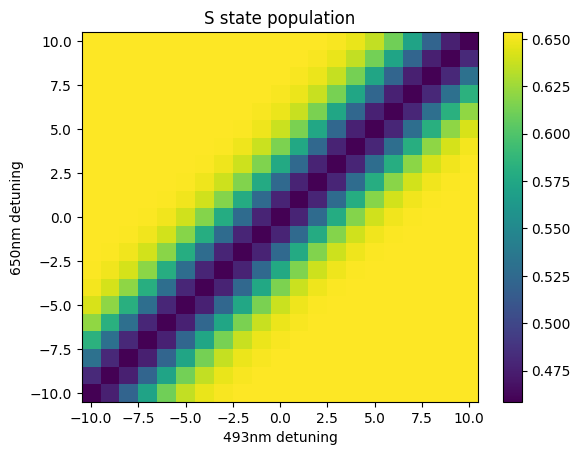

In [500]:
fig = plt.figure()
ax = fig.add_subplot(111)
p = ax.pcolormesh(detunning_493 / Units.MHz, detunning_650 / Units.MHz, np.array(population_S)[..., -1])
plt.colorbar(p)
ax.set_title("S state population")
ax.set_xlabel("493nm detuning")
ax.set_ylabel("650nm detuning")

Text(0, 0.5, '650nm detuning')

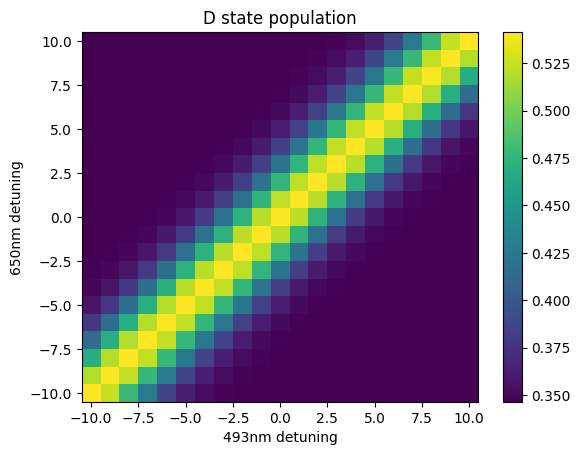

In [501]:
fig = plt.figure()
ax = fig.add_subplot(111)
p = ax.pcolormesh(detunning_493 / Units.MHz, detunning_650 / Units.MHz, np.array(population_D)[..., -1])
plt.colorbar(p)
ax.set_title("D state population")
ax.set_xlabel("493nm detuning")
ax.set_ylabel("650nm detuning")